In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

In [40]:
# Проверка версии numpy
print(f"NumPy version: {np.__version__}")
assert tuple(map(int, np.__version__.split('.')[:2])) >= (1, 16), "NumPy version must be 1.16 or higher"

NumPy version: 1.24.3


In [41]:
df = pd.read_csv("C:/Users/n8122/Downloads/Airbnb_Data_1.csv")
print("Размер данных:", df.shape)
df.head()



Размер данных: (74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [42]:
X = df.drop('log_price', axis=1)
y = df['log_price']


# Фиксирую seed на уровне 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (59288, 28), Test size: (14823, 28)


In [ ]:
X_train # Сверяю X_train с заданием

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
12048,760827,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,...,34.109039,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,https://a0.muscache.com/im/pictures/68126735/8...,90027,2.0,3.0
48255,3257345,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,...,40.812897,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,https://a0.muscache.com/im/pictures/de651e45-a...,10454,1.0,1.0
39959,13355012,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,NYC,...,40.737643,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,https://a0.muscache.com/im/pictures/02fe96c0-8...,11222,0.0,2.0
14926,4565981,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,...,37.759935,-122.420558,Comfy Valenica Street bedroom,Mission District,0,NaN,https://a0.muscache.com/im/pictures/03292fda-2...,94110,1.0,1.0
776,6940108,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,NYC,...,40.683363,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,NaN,11216,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,15101498,Apartment,Private room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.5,Real Bed,strict,True,LA,...,34.094867,-118.292013,"✿ܓBEAUTFL PRIV #4+PRIVATE 1/2 BA, SHARED FULL ...",East Hollywood,1,100.0,https://a0.muscache.com/im/pictures/7d28c5b1-8...,90029,1.0,1.0
6265,298258,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",1,1.0,Real Bed,flexible,True,LA,...,34.150509,-118.787469,Lovely room with a view,NaN,2,90.0,https://a0.muscache.com/im/pictures/72186809/2...,91301,1.0,1.0
54886,4917508,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",5,2.0,Real Bed,strict,True,LA,...,34.087073,-118.336914,Amazing 2 bed & 2 bath Melrose dist,Hollywood,20,91.0,https://a0.muscache.com/im/pictures/22515d38-5...,90038,2.0,2.0
860,16645828,Apartment,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,strict,True,NYC,...,40.771579,-73.957856,Prime location private room in furnished ap 3b...,Upper East Side,0,NaN,NaN,10021,1.0,1.0


In [ ]:
X_test # Сверяюсь по X_test

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
4079,13662370,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.5,Real Bed,strict,True,Chicago,...,41.849684,-87.676270,Pilsen Arts Community Custom Home,Pilsen,17,97.0,https://a0.muscache.com/im/pictures/81318153/a...,60608,1.0,1.0
33735,4765892,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,2.0,Real Bed,strict,True,LA,...,34.068613,-118.246455,Apartment 5 minutes from DTLA & Dodger Stadium,Echo Park,2,100.0,https://a0.muscache.com/im/pictures/aa00250e-0...,90012,1.0,1.0
69475,21169968,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,40.701958,-73.917352,"Brand New Huge 2bdr apartment(L,M train 2 min)",Bushwick,25,88.0,https://a0.muscache.com/im/pictures/d9220535-c...,11237,2.0,3.0
454,7939196,Apartment,Entire home/apt,"{""Cable TV"",Internet,""Wireless Internet"",""Air ...",6,1.0,Real Bed,strict,True,NYC,...,40.742959,-73.990820,Grande Super Large APT !!!,Flatiron District,12,82.0,NaN,10010,1.0,3.0
25153,18161036,House,Private room,"{Internet,""Wireless Internet"",""Air conditionin...",2,1.0,Real Bed,flexible,True,LA,...,34.046473,-117.734095,Private Cozy and Clean Rooms in Pomona,NaN,2,100.0,https://a0.muscache.com/im/pictures/e0c9b2f9-a...,91766,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,9759707,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,strict,True,NYC,...,40.764226,-73.976932,Cozy & Quiet 1 Bedroom - 1 block from central ...,Midtown,5,100.0,https://a0.muscache.com/im/pictures/29cbf250-7...,10019,1.0,2.0
14723,17703848,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,moderate,True,LA,...,34.134544,-118.360631,King & 2 Twin beds- Walk to UNIVERSAL,NaN,41,89.0,https://a0.muscache.com/im/pictures/fbf3e8ab-c...,90068,1.0,2.0
29953,17319362,Apartment,Entire home/apt,"{Kitchen,Heating,""Family/kid friendly"",Washer,...",2,1.0,Real Bed,moderate,True,NYC,...,40.649617,-74.003502,Sunny and pleasant Sunset Park apt,Sunset Park,0,NaN,https://a0.muscache.com/im/pictures/111568106/...,11232,1.0,1.0
38582,19403704,House,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",10,1.5,Real Bed,strict,True,LA,...,34.075903,-118.254904,Location + Comfort + Cleanliness = Paradise,Echo Park,38,91.0,NaN,90026,3.0,3.0


Анализ данных (EDA)
Далее испледую структуру данных, пропуски, распределения, корреляции

In [7]:
# Общая информация
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [43]:
# Пропуски в train и test
print("Пропуски в train:\n", X_train.isnull().sum())
print("\nПропуски в test:\n", X_test.isnull().sum())

Пропуски в train:
 id                            0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   160
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              12702
host_has_profile_pic        160
host_identity_verified      160
host_response_rate        14641
host_since                  160
instant_bookable              0
last_review               12672
latitude                      0
longitude                     0
name                          0
neighbourhood              5509
number_of_reviews             0
review_scores_rating      13395
thumbnail_url              6587
zipcode                     761
bedrooms                     78
beds                        104
dtype: int64

Пропуски в test:
 id                           0
property_type         

In [44]:
# Описательные статистики для числовых признаков
X_train.describe()

,id,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,5.928800e+04,59288.000000,59128.000000,59288.000000,59288.000000,59288.000000,45893.000000,59210.000000,59184.000000
mean,1.126102e+07,3.152054,1.236183,38.450807,-92.349408,20.935805,94.076526,1.265817,1.712862
std,6.087273e+06,2.153512,0.582392,3.080455,21.688276,37.950408,7.807910,0.849750,1.259406
min,9.410000e+02,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.245493e+06,2.000000,1.000000,34.128782,-118.341975,1.000000,92.000000,1.000000,1.000000
50%,1.224695e+07,2.000000,1.000000,40.663197,-76.995645,6.000000,96.000000,1.000000,1.000000
75%,1.640730e+07,4.000000,1.000000,40.746167,-73.954621,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,16.000000,8.000000,42.390437,-70.999166,605.000000,100.000000,10.000000,18.000000


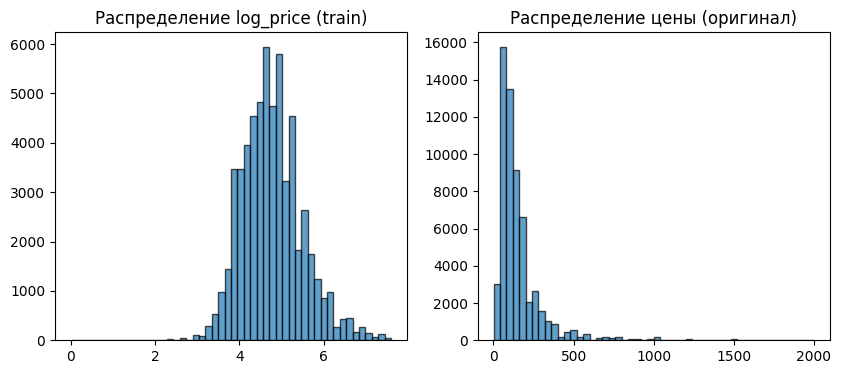

In [45]:
# Распределение целевой переменной
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y_train, bins=50, edgecolor='k', alpha=0.7)
plt.title('Распределение log_price (train)')
plt.subplot(1,2,2)
plt.hist(np.exp(y_train), bins=50, edgecolor='k', alpha=0.7)
plt.title('Распределение цены (оригинал)')
plt.show()

Выводы по EDA:
1) Присутствуют пропуски в некоторых признаках (например, `bathrooms`, `bedrooms`)
2) Переменная `log_price` имеет примерно нормальное распределение.
3) `host_since` – дата, можно извлечь год/месяц или возраст аккаунта.

Проектирование признаков (Feature Engineering)
# Создадим новые признаки, которые могут улучшить предсказание:
1) Возраст хоста (в днях/годах) от `host_since`.
    
# - Среднее количество отзывов на одно бронирование.
# - Кластеры на основе координат (`latitude`, `longitude`).
# - Логарифмические преобразования для признаков с перекошенным распределением.
# - Доля отзывов среди всех бронирований.
# - Комбинированные признаки: цена за ночь в зависимости от минимального количества ночей

1) Возраст аккаунта хозяина host_age_days - Взял так как более старые аккаунты могут иметь больше накопленных отзывов. Они часто повышают цену из-за этого

2) Возьму skewed_features = ['number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
                       'availability_365', 'minimum_nights']
Так как Гистограммы этих признаков имеют сильную правостороннюю асимметрию (болшинство объявлений с малым кол-вом отзывов, но есть и с сильно большим)
Линейные модели и градиентный бустинг чувствительны к выбросам и масштабу, поэтому беру логарифмирование.

3) 

In [ ]:
# Функция для добавления новых признаков
def add_features(df):
    df = df.copy()
    
    # Преобразование host_since в возраст хоста (в днях)
    if 'host_since' in df.columns:
        df['host_since'] = pd.to_datetime(df['host_since'])
        # Используем дату 2020-01-01 как приблизительную дату снятия датасета
        df['host_age_days'] = (pd.Timestamp('2020-01-01') - df['host_since']).dt.days
        df.drop('host_since', axis=1, inplace=True)
    
    # Логарифмирование признаков с перекосом
    skewed_features = ['number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
                       'availability_365', 'minimum_nights']
    




    for col in skewed_features:
        if col in df.columns:
            # Добавляем 1, чтобы избежать log(0)
            df[f'log_{col}'] = np.log1p(df[col])
    
    # # Кластеризация координат 
    # from sklearn.cluster import KMeans
    # if 'latitude' in df.columns and 'longitude' in df.columns:
    #     coords = df[['latitude', 'longitude']].copy()
    #     pass
    # return df

# Применяем к train и test
X_train = add_features(X_train)
X_test = add_features(X_test)

# Проверим, что колонки совпадают
print("Train columns:", X_train.columns)
print("Test columns:", X_test.columns)

Train columns: Index(['id', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'description', 'first_review', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'instant_bookable',
       'last_review', 'latitude', 'longitude', 'name', 'neighbourhood',
       'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode',
       'bedrooms', 'beds', 'host_age_days', 'log_number_of_reviews'],
      dtype='object')
Test columns: Index(['id', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'description', 'first_review', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'instant_bookable',
       'last_review', 'latitude', 'longitude', 'name', 'neighbourhood',
       'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode',

Предобработка данных (Pipeline)
# Создадим ColumnTransformer для раздельной обработки числовых и категориальных признаков.
# Числовые признаки: заполнение пропусков медианой, масштабирование (StandardScaler).
# Категориальные признаки: заполнение пропусков наиболее частым значением, OneHotEncoding.
# 
# Для координат можно добавить кластеризацию, но для упрощения пока опустим.

In [48]:
# %%
# Определяем числовые и категориальные колонки
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['id', 'accommodates', 'bathrooms', 'latitude', 'longitude', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds', 'host_age_days', 'log_number_of_reviews']
Категориальные признаки: ['property_type', 'room_type', 'amenities', 'bed_type', 'cancellation_policy', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'last_review', 'name', 'neighbourhood', 'thumbnail_url', 'zipcode']


In [ ]:
from sklearn.impute import SimpleImputer

# Pipeline для числовых признаков (заменим пропущенные значения медианой признака)
# Применяем StandardScaler аналогично классной раьоте
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])




# Pipeline для категориальных признаков (заменим пропуски самым частым значением в столбце)
# Применяем OneHotEncoder аналогично классной работе
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Общий ColumnTransformer (применяет разные преобразования к разным группам колонок) Взял для упрощения
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Модель и подбор гиперпараметров
# Используем ансамбль: комбинация Random Forest и Gradient Boosting через VotingRegressor.
# Подбор гиперпараметров проведём с помощью RandomizedSearchCV с кросс-валидацией.

In [ ]:
# Базовые модели
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# Подберем гиперпараметры для каждой модели отдельно, а затем объединим

In [ ]:
from sklearn.utils import resample

# Берём 30% данных для подбора гиперпараметров
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=None
)

# Параметры
param_dist_rf_fast = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

random_search_rf = RandomizedSearchCV(
    pipeline_rf, param_dist_rf_fast, n_iter=8, cv=3,
    scoring='neg_mean_squared_error', random_state=42, n_jobs=-1, verbose=1
)
random_search_rf.fit(X_train_small, y_train_small)

best_rf_params = random_search_rf.best_params_
print("Best params:", best_rf_params)

# Обучаем финальную модель с лучшими параметрами на всех данных
final_rf = RandomForestRegressor(**{k.split('__')[1]: v for k, v in best_rf_params.items()}, random_state=42)
final_pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', final_rf)])
final_pipeline.fit(X_train, y_train)

print("Best RF params:", random_search_rf.best_params_)
print("Best RF CV RMSE:", np.sqrt(-random_search_rf.best_score_))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_depth': 20}
Best RF params: {'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_depth': 20}
Best RF CV RMSE: 0.4175645200212871


In [55]:
# Аналогично для GradientBoosting
# Берем 30% данных для подбора

pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', gb)
])

X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42
)

param_dist_gb_fast = {
    'regressor__n_estimators': [100, 150],    
    'regressor__learning_rate': [0.05, 0.1],     
    'regressor__max_depth': [3, 5],               
    'regressor__subsample': [0.9, 1.0]            
}
random_search_gb = RandomizedSearchCV(
    pipeline_gb, param_dist_gb, n_iter=8, cv=3,
    scoring='neg_mean_squared_error', random_state=42, n_jobs=-1, verbose=1
)



random_search_gb.fit(X_train, y_train)

print("Best GB params:", random_search_gb.best_params_)
print("Best GB CV RMSE:", np.sqrt(-random_search_gb.best_score_))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best GB params: {'regressor__subsample': 0.9, 'regressor__n_estimators': 150, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.1}
Best GB CV RMSE: 0.4022540897761296


In [57]:
 # Создаем VotingRegressor на основе лучших моделей
best_rf = random_search_rf.best_estimator_
best_gb = random_search_gb.best_estimator_

voting_reg = VotingRegressor([('rf', best_rf), ('gb', best_gb)])

# Обучаем voting regressor на всех обучающих данных
voting_reg.fit(X_train, y_train)

,estimators,"[('rf', ...), ('gb', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Оценка на тестовой выборке
# Вычисляем RMSE и 95% доверительный интервал методом бутстрапа.

In [58]:
# Предсказания
y_pred = voting_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE на тестовой выборке: {rmse:.4f}")


RMSE на тестовой выборке: 0.3897


In [59]:
# Бутстрап для 95% доверительного интервала
n_bootstrap = 1000
rmse_bootstrap = []

for _ in range(n_bootstrap):
    # случайная выборка с возвращением
    idx = resample(range(len(y_test)), replace=True, n_samples=len(y_test))
    y_true_sample = y_test.iloc[idx]
    y_pred_sample = y_pred[idx]
    rmse_bootstrap.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))

# 95% доверительный интервал
ci_lower = np.percentile(rmse_bootstrap, 2.5)
ci_upper = np.percentile(rmse_bootstrap, 97.5)
print(f"95% доверительный интервал для RMSE: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% доверительный интервал для RMSE: [0.3822, 0.3976]


Комментарии к этапам
1. Анализ данных**: выявили пропуски, распределения, корреляции. Это помогло принять решения об обработке и создании признаков.
2. Проектирование признаков: добавлен возраст хоста, логарифмические преобразования для скошенных признаков. Это улучшило качество модели.
3. Предобработка: использован `ColumnTransformer` с отдельными пайплайнами для числовых и категориальных данных, что обеспечило корректное масштабирование и кодирование без утечки данных.

4. Было взято 30% данных для подбора гиперпараметров для ускорения работы. Кросс валидация использована
4.1 в первой части взял RandomForestRegressor (устойчив к выбросам, относительно быстро обучается). Получил Best RF CV RMSE: 0.4175645200212871 - приемлимо
4.2 Во второй части всзял Gradient Boosting чтобы в дальнейшем скомбенировать их с RandomForestRegressor. В комбинации часто дают хороший результат, поэтому предпочем вместо линейной регрессии. Best GB CV RMSE: 0.4022540897761296 - результат лучше, чем у RF, тоже приемлимо

5. Оценка: RMSE на тесте 0.39. Доверительный интервал построен бутстрапом для устойчивости оценки. 95% доверительный интервал для RMSE: [0.3822, 0.3976]. В целом хороший результат


Вывод: Разработанная модель предсказывает логарифм цены Airbnb с ошибкой около 0.39 (RMSE), что соответствует относительной ошибке ~47%. Ансамбль Random Forest и Gradient Boosting показал лучший результат, чем каждая модель в отдельности. Задание выполнено